In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import gc
from opacus import PrivacyEngine
from torch.utils.data import random_split


transform = transforms.Compose([
    transforms.ToTensor(),  
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_size_private = int(0.96 * len(train_dataset))
train_size_public = len(train_dataset) - train_size_private
train_dataset_public, train_dataset_private = random_split(train_dataset, [train_size_public, train_size_private])
train_loader_public = DataLoader(dataset=train_dataset_public, batch_size=64, shuffle=True)
train_loader_private = DataLoader(dataset=train_dataset_private, batch_size=64, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)  # Flatten the tensor
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = mnist()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

privacy_engine = PrivacyEngine()


gc.collect()

/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


0

In [4]:
epochs_1 = 5
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
for epoch in range(epochs_1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_public:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))  
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()

Epoch [1/10]
Training loss 2.292014958063761
Training accuracy 19.208333333333332 %
Testing loss 0.5500835899353027
Testing accuracy 27.77 %
Epoch [2/10]
Training loss 2.228855396906535
Training accuracy 32.416666666666664 %
Testing loss 0.5349252952575684
Testing accuracy 43.84 %
Epoch [3/10]
Training loss 1.8012195173899332
Training accuracy 48.625 %
Testing loss 0.43229268417358396
Testing accuracy 61.58 %
Epoch [4/10]
Training loss 1.0070897936820984
Training accuracy 70.25 %
Testing loss 0.24170155048370362
Testing accuracy 78.17 %
Epoch [5/10]
Training loss 0.6453550577163696
Training accuracy 81.375 %
Testing loss 0.15488521385192872
Testing accuracy 83.24 %


In [5]:
epochs_1 = 5
train_losses_2 = []
train_accuracies_2 = []
test_losses_2 = []
test_accuracies_2 = []
model.train()
model, optimizer, train_loader_private = privacy_engine.make_private_with_epsilon(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader_private,
    epochs=10,
    target_epsilon=3,
    target_delta=1e-5,
    max_grad_norm=0.1,
)
epochs_2 = 10
for epoch in range(epochs_2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_private:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))
    train_losses_2.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies_2.append(correct * 100 / total)
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses_2.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies_2.append(correct * 100 / total)

    gc.collect()

/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Epoch [1/10]
Training loss 0.5935594701162922
Training accuracy 80.3585925759591 %
Testing loss 3.4362938403442502
Testing accuracy 80.9 %
Epoch [2/10]
Training loss 0.5839908568116011
Training accuracy 81.23842011393742 %
Testing loss 3.3726055971726776
Testing accuracy 82.33 %
Epoch [3/10]
Training loss 0.557465399871126
Training accuracy 82.40048564738531 %
Testing loss 3.214066762956977
Testing accuracy 83.65 %
Epoch [4/10]
Training loss 0.5611691796552116
Training accuracy 83.14380807100264 %
Testing loss 3.237272763594985
Testing accuracy 84.71 %
Epoch [5/10]
Training loss 0.5363002102328108
Training accuracy 84.24340502540544 %
Testing loss 3.0820100481659174
Testing accuracy 85.27 %
Epoch [6/10]
Training loss 0.5258547650683738
Training accuracy 85.20984281242976 %
Testing loss 3.040965520913899
Testing accuracy 86.3 %
Epoch [7/10]
Training loss 0.5151141390363946
Training accuracy 85.80330722367276 %
Testing loss 2.959330728764087
Testing accuracy 86.88 %
Epoch [8/10]
Training

In [6]:
model.eval()
correct = 0
total = 0
eval_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        eval_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")

Test Loss: 0.4801, Accuracy: 87.91%


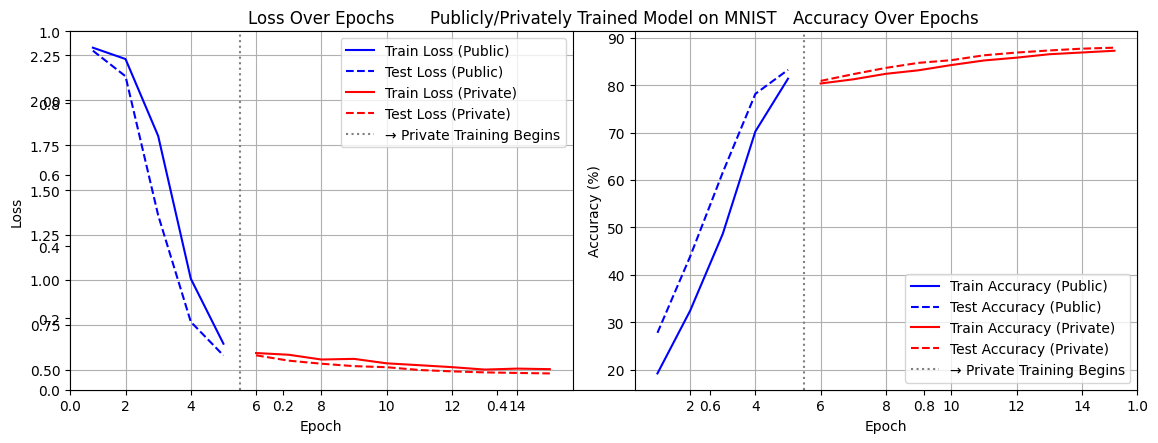

In [11]:
import matplotlib.pyplot as plt

# Combine loss and accuracy for plotting
full_train_losses = train_losses + train_losses_2
full_test_losses = test_losses + test_losses_2
full_train_accuracies = train_accuracies + train_accuracies_2
full_test_accuracies = test_accuracies + test_accuracies_2

# Create epoch ranges
public_epochs = list(range(1, epochs_1 + 1))
private_epochs = list(range(epochs_1 + 1, epochs_1 + epochs_2 + 1))

plt.figure(figsize=(12, 5))
plt.title('Publicly/Privately Trained Model on MNIST')
# --- Loss Plot ---
plt.subplot(1, 2, 1)
# Public Phase
plt.plot(public_epochs, train_losses, 'b-', label='Train Loss (Public)')
plt.plot(public_epochs, test_losses, 'b--', label='Test Loss (Public)')

# Private Phase
plt.plot(private_epochs, train_losses_2, 'r-', label='Train Loss (Private)')
plt.plot(private_epochs, test_losses_2, 'r--', label='Test Loss (Private)')

plt.axvline(x=epochs_1 + 0.5, color='gray', linestyle=':', label='→ Private Training Begins')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True)

# --- Accuracy Plot ---
plt.subplot(1, 2, 2)
# Public Phase
plt.plot(public_epochs, train_accuracies, 'b-', label='Train Accuracy (Public)')
plt.plot(public_epochs, test_accuracies, 'b--', label='Test Accuracy (Public)')

# Private Phase
plt.plot(private_epochs, train_accuracies_2, 'r-', label='Train Accuracy (Private)')
plt.plot(private_epochs, test_accuracies_2, 'r--', label='Test Accuracy (Private)')

plt.axvline(x=epochs_1 + 0.5, color='gray', linestyle=':', label='→ Private Training Begins')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
